In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import ipywidgets as widgets
from IPython.display import display, clear_output


def generate_data(n_samples=100):
    np.random.seed(42)
    X = np.random.uniform(-1, 1, (n_samples, 1))
    y = 2 * X + np.sin(3 * X) + np.random.normal(0, 0.1, (n_samples, 1))
    return X, y

In [22]:
class TwoLayerNN:
    def __init__(self, input_dim, hidden_dim, output_dim):
        np.random.seed(42)
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.1
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.1
        self.b2 = np.zeros((1, output_dim))
    
    def forward(self, X):
        self.z1 = X.dot(self.W1) + self.b1
        self.a1 = np.tanh(self.z1)
        self.z2 = self.a1.dot(self.W2) + self.b2
        return self.z2
    
    def compute_loss(self, y_pred, y_true):
        return 0.5 * np.mean((y_pred - y_true) ** 2)
    
    def update_weights(self, grad_W1, grad_W2, lr=0.01):
        self.W1 -= lr * grad_W1
        self.W2 -= lr * grad_W2

In [24]:
# Compute error surface
def compute_error_surface(nn, X, y, w1_range=(-1, 1), w2_range=(-1, 1), resolution=30):
    W1_vals = np.linspace(w1_range[0], w1_range[1], resolution)
    W2_vals = np.linspace(w2_range[0], w2_range[1], resolution)
    
    loss_surface = np.zeros((resolution, resolution))
    
    for i, w1 in enumerate(W1_vals):
        for j, w2 in enumerate(W2_vals):
            nn.W1[0, 0] = w1
            nn.W2[0, 0] = w2
            y_pred = nn.forward(X)
            loss_surface[i, j] = nn.compute_loss(y_pred, y)
    
    return W1_vals, W2_vals, loss_surface

# Visualize error surface
def plot_error_surface(W1_vals, W2_vals, loss_surface):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    W1_vals, W2_vals = np.meshgrid(W1_vals, W2_vals)
    ax.plot_surface(W1_vals, W2_vals, loss_surface, cmap=cm.viridis, alpha=0.7)
    ax.set_xlabel('W1')
    ax.set_ylabel('W2')
    ax.set_zlabel('Loss')
    ax.set_title('Error Surface')
    plt.show()


In [26]:
# Optimizer implementations
def train_optimizer(nn, X, y, lr=0.01, epochs=50, optimizer='sgd', beta=0.9, eps=1e-8):
    v_W1, v_W2 = 0, 0
    s_W1, s_W2 = 0, 0
    loss_history = []
    
    for epoch in range(epochs):
        y_pred = nn.forward(X)
        loss = nn.compute_loss(y_pred, y)
        loss_history.append(loss)
        
        grad_W2 = np.dot(nn.a1.T, (y_pred - y)) / X.shape[0]
        grad_W1 = np.dot(X.T, np.dot((y_pred - y), nn.W2.T) * (1 - np.tanh(nn.z1) ** 2)) / X.shape[0]
        
        if optimizer == 'momentum':
            v_W1 = beta * v_W1 + (1 - beta) * grad_W1
            v_W2 = beta * v_W2 + (1 - beta) * grad_W2
            nn.update_weights(v_W1, v_W2, lr)
        
        elif optimizer == 'rmsprop':
            s_W1 = beta * s_W1 + (1 - beta) * (grad_W1 ** 2)
            s_W2 = beta * s_W2 + (1 - beta) * (grad_W2 ** 2)
            nn.update_weights(grad_W1 / (np.sqrt(s_W1) + eps), grad_W2 / (np.sqrt(s_W2) + eps), lr)
        
        elif optimizer == 'adam':
            v_W1 = beta * v_W1 + (1 - beta) * grad_W1
            v_W2 = beta * v_W2 + (1 - beta) * grad_W2
            s_W1 = beta * s_W1 + (1 - beta) * (grad_W1 ** 2)
            s_W2 = beta * s_W2 + (1 - beta) * (grad_W2 ** 2)
            nn.update_weights(v_W1 / (np.sqrt(s_W1) + eps), v_W2 / (np.sqrt(s_W2) + eps), lr)
        
        elif optimizer == 'adagrad':
            s_W1 += grad_W1 ** 2
            s_W2 += grad_W2 ** 2
            nn.update_weights(grad_W1 / (np.sqrt(s_W1) + eps), grad_W2 / (np.sqrt(s_W2) + eps), lr)
        
        else:  # SGD
            nn.update_weights(grad_W1, grad_W2, lr)
    
    return loss_history


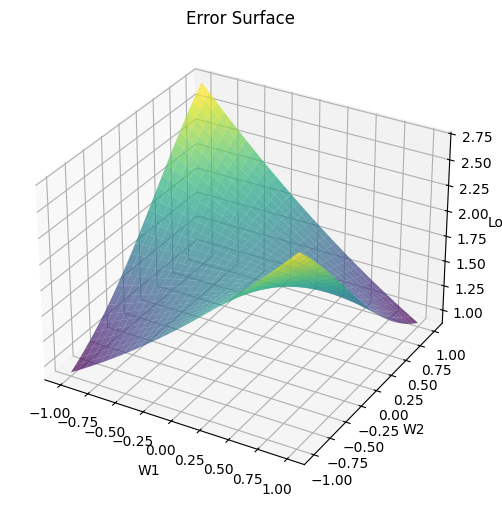

Dropdown(description='Optimizer:', options=('sgd', 'momentum', 'rmsprop', 'adam', 'adagrad'), value='sgd')

FloatSlider(value=0.01, description='Learning Rate:', max=0.1, min=0.001, step=0.001)

IntSlider(value=50, description='Epochs:', max=200, min=10, step=10)

Button(description='Train', style=ButtonStyle())

Output()

In [28]:
def interactive_training():
    X, y = generate_data()
    nn = TwoLayerNN(input_dim=1, hidden_dim=5, output_dim=1)
    
    optimizer_dropdown = widgets.Dropdown(options=['sgd', 'momentum', 'rmsprop', 'adam', 'adagrad'], description='Optimizer:')
    lr_slider = widgets.FloatSlider(value=0.01, min=0.001, max=0.1, step=0.001, description='Learning Rate:')
    epochs_slider = widgets.IntSlider(value=50, min=10, max=200, step=10, description='Epochs:')
    button = widgets.Button(description="Train")
    output = widgets.Output()
    
    def on_button_click(b):
        with output:
            clear_output(wait=True)
            loss_history = train_optimizer(nn, X, y, lr=lr_slider.value, epochs=epochs_slider.value, optimizer=optimizer_dropdown.value)
            plt.plot(loss_history)
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.title(f'Training Loss using {optimizer_dropdown.value}')
            plt.show()
    
    button.on_click(on_button_click)
    display(optimizer_dropdown, lr_slider, epochs_slider, button, output)

# Run the setup
X, y = generate_data()
nn = TwoLayerNN(input_dim=1, hidden_dim=5, output_dim=1)
W1_vals, W2_vals, loss_surface = compute_error_surface(nn, X, y)
plot_error_surface(W1_vals, W2_vals, loss_surface)
interactive_training()
